 #  **2.2 Impact Model Fitting**

In this section, we fit price impact models using the in-sample public trading tape. The goal is to estimate how signed market order flow affects future price changes. Following the lecture methodology, we assume that observed price changes can be decomposed into a fundamental price move plus a price impact component:
$$
\frac{I_{t+\Delta t}}{\lambda}
=
e^{-\beta \Delta t}
\frac{I_t}{\lambda}
+
\sigma_i
\frac{q_t}{ADV_i}.

\qquad \beta = \frac{\log 2}{\text{half-life}};
$$

$$
\begin{aligned}
\Delta P_t &= \text{actual observed price change}, \\
\Delta S_t &= \text{fundamental price move, unrelated to our trades}, \\
\Delta I_t(Q) &= \text{price move caused by trading or order flow } Q.
\end{aligned}
$$

Since the fundamental price move $\Delta S_t$ is not directly observable, we cannot separate the observed price change into a fundamental component and an impact component exactly. Therefore, in the regression, we treat it as noise.


We observe the total price change $\Delta P_t$ and then build a model-implied impact state $I_t$ from the observed signed trades $Q$. The regression checks whether changes in this impact state help explain observed price changes.

We estimate

$$
r_{i,d,t}^{(H)}
=
\alpha_i
+
\lambda_i \Delta I_{i,d,t}^{(H)}
+
\varepsilon_{i,d,t}
$$

$$
r_{i,d,t}^{(H)}
=
\frac{P_{i,d,t}}{P_{i,d,t-H}}
-
1
$$

$$
\Delta I_{i,d,t}^{(H)}
=
I_{i,d,t}
-
I_{i,d,t-H}.
$$

where $\lambda$ is the fitted impact coefficient, and $\varepsilon_t$ contains the unobserved fundamental price move.

The interpretation is that if $\Delta I_t$ tends to explain observed returns, then the model-implied impact state captures part of the price impact in the data.

We fit three impact models:

#### 1. OW model - The Obizhaeva–Wang Model:

Assumes linear price impact with exponential decay:$$I_{t+\Delta t} = e^{-\beta \Delta t} I_t + \lambda \sigma_i \frac{q_t}{ADV_i}$$where:
- $q_t$ is signed traded volume,
- $ADV_i$ is the average daily volume of stock $i$,
- $\sigma_i$ is the stock-level volatility scale,
- $\lambda$ is the impact coefficient,
- $\beta$ controls the impact decay speed.

#### 2. The AFS-style Model: 

First computes a linear volume-space impact state $J_t$ and then applies a square-root transformation:$$I_t = \operatorname{sign}(J_t)\sqrt{|J_t|}$$This captures the idea that price impact may be concave for larger orders.

#### 3. Reduced-form dynamic-liquidity model

The reduced-form model allows liquidity to vary over time. It estimates a local volume state $v_t$ and scales signed order flow by local market activity:
$$
I_{t+\Delta t} - I_t=-\beta I_t \Delta t+\lambda \sigma_i\frac{q_t}{\sqrt{ADV_i v_t}}; \qquad
v_t
=
e^{-\beta \Delta t}
v_{t-1}
+
|q_t|.
$$

where $v_t$ is an exponentially weighted estimate of recent unsigned traded volume.

- same trade during quiet market  -> larger impact
- same trade during active market -> smaller impact

##### **Implementation**

For each model, we first compute the normalized impact state using $\lambda = 1$. Then, for a given horizon $h$, we compute the model-implied impact change:$$\Delta_h I_t = I_{t+h} - I_t$$and the realized forward return:$$r_{t,h} = \frac{P_{t+h} - P_t}{P_t}$$We estimate the impact coefficient $\lambda$ from the in-sample data using the regression:$$r_{t,h} = a + \lambda \Delta_h I_t + \varepsilon_t$$The fitted $\lambda$ is then evaluated on both the in-sample month and the out-of-sample month.

**OLS Regression**:
$$
y = \alpha + \lambda x + \varepsilon.
$$

$$
\hat{\lambda}
=
\frac{
\sum xy - \frac{\sum x \sum y}{n}
}{
\sum x^2 - \frac{(\sum x)^2}{n}
}.
$$

$$
\hat{\alpha}
=
\frac{\sum y}{n}
-
\hat{\lambda}
\frac{\sum x}{n}.
$$

To compute $R^2$ later:

$$
TSS
=
\sum y^2
-
\frac{(\sum y)^2}{n}.
$$

The outputs of this section are:
- fitted $\lambda$ for each stock, model, and half-life,
- in-sample $R^2$,
- out-of-sample $R^2$,
- a grid-search summary over different impact half-lives,
- the best half-life for each model, selected using in-sample $R^2$,
- CSV files containing the stock-level results, model summary, and best model choices.

This completes the baseline coursework requirement of fitting the OW model together with more advanced impact models using the in-sample public trading tape.

### Imports and Data Loading

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import src.impact_model_fitting

importlib.reload(src.impact_model_fitting)

from src.impact_model_fitting import *

In [3]:
# Load data
result_path = "data/"

train_traded_volume_df = pd.read_csv(
    os.path.join(result_path, "train_traded_volume_201901_20.csv"),
    index_col=[0, 1]
)

test_traded_volume_df = pd.read_csv(
    os.path.join(result_path, "test_traded_volume_201902_20.csv"),
    index_col=[0, 1]
)

train_px_df = pd.read_csv(
    os.path.join(result_path, "train_px_201901_20.csv"),
    index_col=[0, 1]
)

test_px_df = pd.read_csv(
    os.path.join(result_path, "test_px_201902_20.csv"),
    index_col=[0, 1]
)

scaling_df = pd.read_csv(
    os.path.join(result_path, "scaling_201901_20.csv"),
    index_col=0
)

In [4]:
# Ensure columns are sorted time strings
train_traded_volume_df = train_traded_volume_df.sort_index().sort_index(axis=1)
test_traded_volume_df = test_traded_volume_df.sort_index().sort_index(axis=1)
train_px_df = train_px_df.sort_index().sort_index(axis=1)
test_px_df = test_px_df.sort_index().sort_index(axis=1)

### Fitting OW Model

In [5]:
# Fit OW model with 1-hour half-life and 1-minute return horizon

ow_result_1h = fit_impact_model_once(
    train_traded_volume_df=train_traded_volume_df,
    test_traded_volume_df=test_traded_volume_df,
    train_px_df=train_px_df,
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    model_type="ow",
    half_life_seconds=3600,
    horizon_periods=6
)

In [8]:
ow_result_1h[[
    "lambda_hat",
    "intercept_hat",
    "is_r2",
    "oos_r2",
    "model_type",
    "half_life_seconds",
    "horizon_minutes"
]].head(30)

,lambda_hat,intercept_hat,is_r2,oos_r2,model_type,half_life_seconds,horizon_minutes
stock,,,,,,,
AAL,261.308683,0.000021,0.144974,0.200245,ow,3600,1.0
AAPL,401.308615,-0.000001,0.228914,0.250962,ow,3600,1.0
ABBV,373.525293,0.000006,0.127553,0.133032,ow,3600,1.0
ABT,436.956233,0.000013,0.171534,0.115861,ow,3600,1.0
ADBE,338.407948,0.000005,0.124307,0.137358,ow,3600,1.0
ADI,337.280208,0.000014,0.136396,0.120700,ow,3600,1.0
ADM,346.803397,0.000005,0.180480,0.271894,ow,3600,1.0
ADP,252.545567,0.000009,0.115532,0.187690,ow,3600,1.0
AEP,267.058792,0.000009,0.135992,0.138497,ow,3600,1.0


### Fitting AFS Model

In [9]:
# Fit the model for half-life of 1 hour and horizon of 6 periods (30 minutes)
afs_result_1h = fit_impact_model_once(
    train_traded_volume_df=train_traded_volume_df,
    test_traded_volume_df=test_traded_volume_df,
    train_px_df=train_px_df,
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    model_type="afs",
    half_life_seconds=3600,
    horizon_periods=6
)


In [10]:
afs_result_1h[[
    "lambda_hat",
    "intercept_hat",
    "is_r2",
    "oos_r2",
    "model_type",
    "half_life_seconds",
    "horizon_minutes"
]].head()

,lambda_hat,intercept_hat,is_r2,oos_r2,model_type,half_life_seconds,horizon_minutes
stock,,,,,,,
AAL,1.199164,0.000018,0.099383,0.147090,afs,3600,1.0
AAPL,1.202785,0.000002,0.141536,0.184163,afs,3600,1.0
ABBV,0.976841,0.000005,0.074426,0.053766,afs,3600,1.0
ABT,0.877120,0.000011,0.106252,0.085768,afs,3600,1.0
ADBE,0.885908,0.000005,0.090679,0.088213,afs,3600,1.0


### Fitting Reduced form model

In [11]:
reduced_result_1h = fit_impact_model_once(
    train_traded_volume_df=train_traded_volume_df,
    test_traded_volume_df=test_traded_volume_df,
    train_px_df=train_px_df,
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    model_type="reduced_form",
    half_life_seconds=3600,
    horizon_periods=6
)

In [ ]:
reduced_result_1h[[
    "lambda_hat",
    "intercept_hat",
    "is_r2",
    "oos_r2",
    "model_type",
    "half_life_seconds",
    "horizon_minutes"
]].head()

,lambda_hat,intercept_hat,is_r2,oos_r2,model_type,half_life_seconds,horizon_minutes
stock,,,,,,,
AAL,131.534402,0.000019,0.161028,0.245336,reduced_form,3600,1.0
AAPL,199.342660,-0.000015,0.251547,0.274540,reduced_form,3600,1.0
ABBV,169.846158,0.000002,0.139889,0.117995,reduced_form,3600,1.0
ABT,191.156939,0.000011,0.177674,0.093045,reduced_form,3600,1.0
ADBE,165.846854,0.000005,0.145684,0.165026,reduced_form,3600,1.0


In [13]:
# Create a summary table comparing the three models
summary_1h = pd.DataFrame({
    "OW": model_summary_table(ow_result_1h),
    "AFS": model_summary_table(afs_result_1h),
    "Reduced Form": model_summary_table(reduced_result_1h)
}).T

display(summary_1h)

,mean_lambda,std_lambda,tstat_lambda,mean_is_r2,mean_oos_r2,median_is_r2,median_oos_r2,n_stocks
OW,341.893925,88.703145,3.854361,0.166948,0.158844,0.146284,0.168222,20.0
AFS,1.013475,0.338594,2.993186,0.111829,0.096533,0.099771,0.101604,20.0
Reduced Form,161.782826,32.532900,4.972899,0.184468,0.162105,0.165532,0.176521,20.0


In [16]:
# Half life = memory of past trades
# Horizon period controls the window used in the regression

# Now we will fit the model for a range of half-life values and compare the results
half_lives_minutes = [1, 5, 10, 15, 30, 60, 120]
half_lives_seconds = [m * 60 for m in half_lives_minutes]

horizon_periods = 6   # 1 minute, because 6 x 10s = 60s

all_results = []

for model_type in ["ow", "afs", "reduced_form"]:
    for half_life_seconds in half_lives_seconds:

        result_df = fit_impact_model_once(
            train_traded_volume_df=train_traded_volume_df,
            test_traded_volume_df=test_traded_volume_df,
            train_px_df=train_px_df,
            test_px_df=test_px_df,
            scaling_df=scaling_df,
            model_type=model_type,
            half_life_seconds=half_life_seconds,
            horizon_periods=horizon_periods
        )

        result_df = result_df.reset_index()
        all_results.append(result_df)

all_results_df = pd.concat(all_results, ignore_index=True)

display(all_results_df.head(20))

,stock,is_xy,is_xx,is_yy,is_x,is_y,is_count,oos_xy,oos_xx,oos_yy,...,is_tss,is_sse,is_r2,oos_tss,oos_sse,oos_r2,model_type,half_life_seconds,horizon_periods,horizon_minutes
0,AAL,0.000020,7.963569e-08,0.053123,-0.000463,0.767815,45381,0.000010,4.932599e-08,0.016615,...,0.053110,0.048041,0.095434,0.016613,0.014682,0.116199,ow,60,6,1.0
1,AAPL,0.000008,1.799641e-08,0.018868,0.000291,0.463981,45381,0.000003,5.876414e-09,0.007774,...,0.018863,0.015639,0.170943,0.007774,0.006331,0.185577,ow,60,6,1.0
2,ABBV,0.000006,1.531135e-08,0.023103,-0.000086,0.171145,45381,0.000004,1.486810e-08,0.009487,...,0.023102,0.021097,0.086799,0.009487,0.008784,0.074078,ow,60,6,1.0
3,ABT,0.000005,1.176923e-08,0.017446,0.000036,0.408693,45381,0.000002,8.135603e-09,0.006989,...,0.017442,0.015692,0.100337,0.006985,0.006547,0.062783,ow,60,6,1.0
4,ADBE,0.000006,2.017601e-08,0.022893,-0.000060,0.332153,45381,0.000003,1.475177e-08,0.010425,...,0.022890,0.021381,0.065942,0.010424,0.009668,0.072479,ow,60,6,1.0
5,ADI,0.000005,1.822431e-08,0.019501,0.000240,0.690522,45381,0.000004,2.044956e-08,0.012198,...,0.019491,0.018204,0.066032,0.012196,0.011321,0.071739,ow,60,6,1.0
6,ADM,0.000004,1.465098e-08,0.012138,0.000066,0.460153,45381,0.000006,2.599122e-08,0.009269,...,0.012133,0.010909,0.100889,0.009268,0.007865,0.151394,ow,60,6,1.0
7,ADP,0.000004,1.928554e-08,0.013531,0.000128,0.318509,45381,0.000003,1.497077e-08,0.005289,...,0.013529,0.012717,0.059991,0.005285,0.004819,0.088141,ow,60,6,1.0
8,AEP,0.000003,1.381270e-08,0.010026,0.000042,0.370379,45381,0.000002,1.122771e-08,0.005080,...,0.010023,0.009224,0.079774,0.005077,0.004766,0.061130,ow,60,6,1.0
9,AES,0.000009,5.154208e-08,0.017857,0.000044,0.740628,45381,0.000007,5.339982e-08,0.010714,...,0.017845,0.016314,0.085779,0.010709,0.009731,0.091312,ow,60,6,1.0


In [15]:
# Create a summary table comparing the results across different half-life values and models
grid_summary = (
    all_results_df
    .groupby(["model_type", "half_life_seconds"])
    .agg(
        mean_lambda=("lambda_hat", "mean"),
        std_lambda=("lambda_hat", "std"),
        mean_is_r2=("is_r2", "mean"),
        mean_oos_r2=("oos_r2", "mean"),
        median_is_r2=("is_r2", "median"),
        median_oos_r2=("oos_r2", "median"),
        n_stocks=("stock", "nunique")
    )
    .reset_index()
)

grid_summary["tstat_lambda"] = (
    grid_summary["mean_lambda"] / grid_summary["std_lambda"]
)

grid_summary["half_life_minutes"] = grid_summary["half_life_seconds"] / 60

grid_summary = grid_summary[
    [
        "model_type",
        "half_life_minutes",
        "mean_lambda",
        "tstat_lambda",
        "mean_is_r2",
        "mean_oos_r2",
        "median_is_r2",
        "median_oos_r2",
        "n_stocks"
    ]
]

display(grid_summary)

,model_type,half_life_minutes,mean_lambda,tstat_lambda,mean_is_r2,mean_oos_r2,median_is_r2,median_oos_r2,n_stocks
0,afs,1.0,0.412077,2.649037,0.123489,0.126232,0.106652,0.125322,20
1,afs,5.0,0.614947,3.077177,0.153022,0.149694,0.142073,0.149931,20
2,afs,10.0,0.707078,3.222049,0.142151,0.137983,0.132173,0.134804,20
3,afs,15.0,0.768599,3.210184,0.134408,0.130369,0.127873,0.127343,20
4,afs,30.0,0.876071,3.167765,0.120397,0.115479,0.110380,0.116697,20
5,afs,60.0,1.013475,2.993186,0.111829,0.096533,0.099771,0.101604,20
6,afs,120.0,1.148356,2.600855,0.106739,0.080378,0.098611,0.096546,20
7,ow,1.0,299.233405,3.107512,0.098229,0.093193,0.085904,0.093997,20
8,ow,5.0,345.502118,3.642581,0.156801,0.146887,0.137902,0.159392,20
9,ow,10.0,347.511095,3.737538,0.164237,0.154111,0.143380,0.166092,20


In [28]:
# Find the best half-life for each model based on in-sample R²
best_by_is = (
    grid_summary
    .sort_values(["model_type", "mean_is_r2"], ascending=[True, False])
    .groupby("model_type")
    .head(1)
)

display(best_by_is)

,model_type,half_life_minutes,mean_lambda,tstat_lambda,mean_is_r2,mean_oos_r2,median_is_r2,median_oos_r2,n_stocks
1,afs,5.0,0.614947,3.077177,0.153022,0.149694,0.142073,0.149931,20
11,ow,30.0,344.553194,3.824627,0.167120,0.158372,0.145917,0.168902,20
16,reduced_form,10.0,85.136470,5.804206,0.196336,0.179360,0.187267,0.194366,20


In [32]:
# Save results to CSV
all_results_df.to_csv(
    os.path.join(result_path, "impact_model_stock_results_201901_train_201902_test.csv"),
    index=False
)

grid_summary.to_csv(
    os.path.join(result_path, "impact_model_grid_summary_201901_train_201902_test.csv"),
    index=False
)

best_by_is.to_csv(
    os.path.join(result_path, "impact_model_best_by_is_201901_train_201902_test.csv"),
    index=False
)

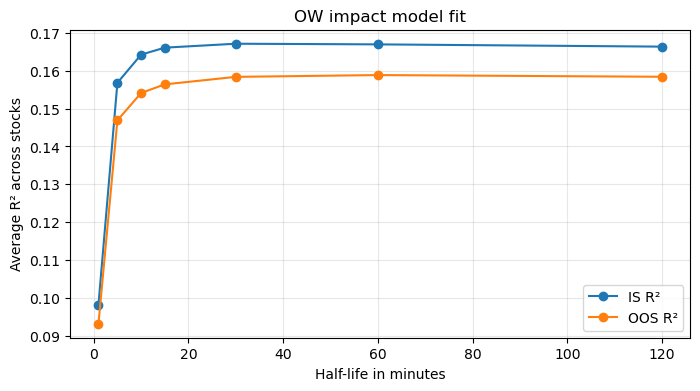

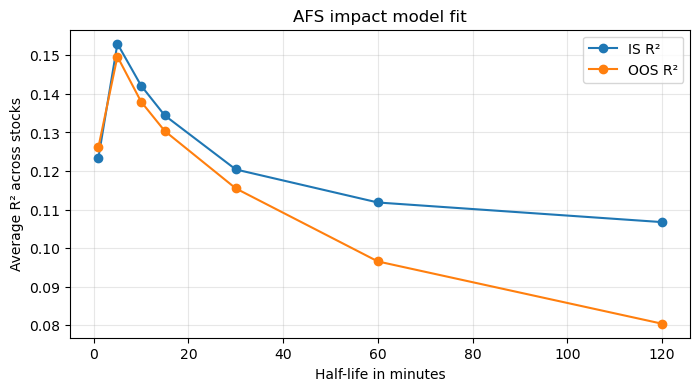

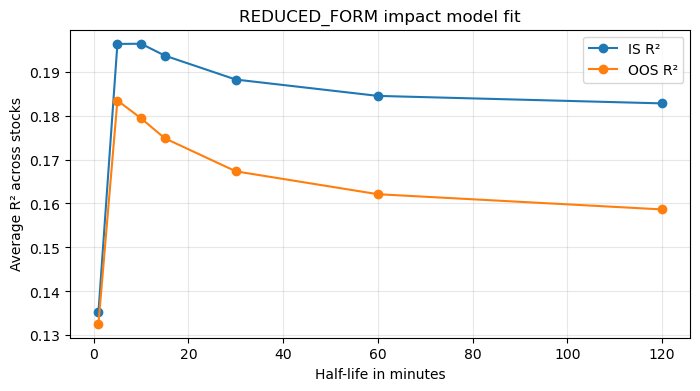

In [29]:
# Plot the results
for model_type in ["ow", "afs", "reduced_form"]:
    sub = grid_summary[grid_summary["model_type"] == model_type]

    plt.figure(figsize=(8, 4))
    plt.plot(sub["half_life_minutes"], sub["mean_is_r2"], marker="o", label="IS R²")
    plt.plot(sub["half_life_minutes"], sub["mean_oos_r2"], marker="o", label="OOS R²")
    plt.xlabel("Half-life in minutes")
    plt.ylabel("Average R² across stocks")
    plt.title(f"{model_type.upper()} impact model fit")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

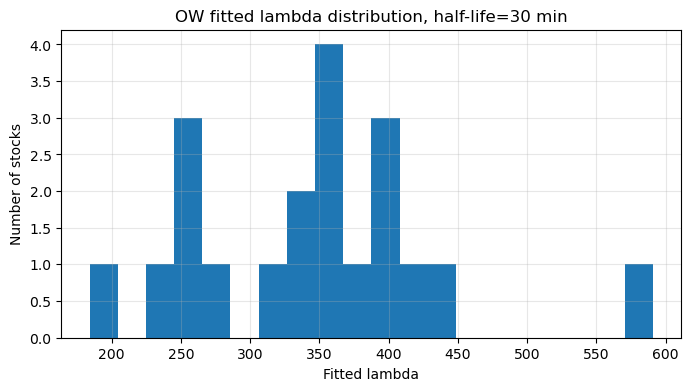

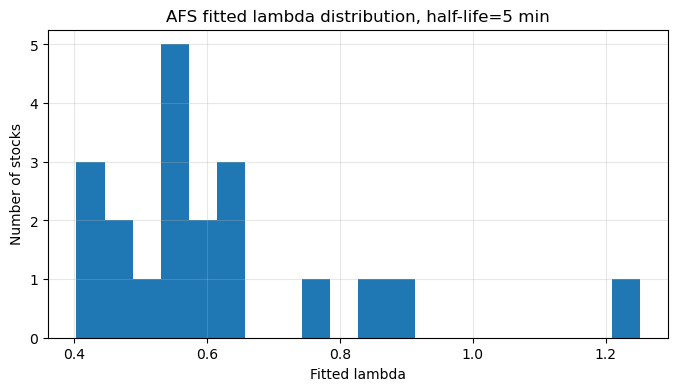

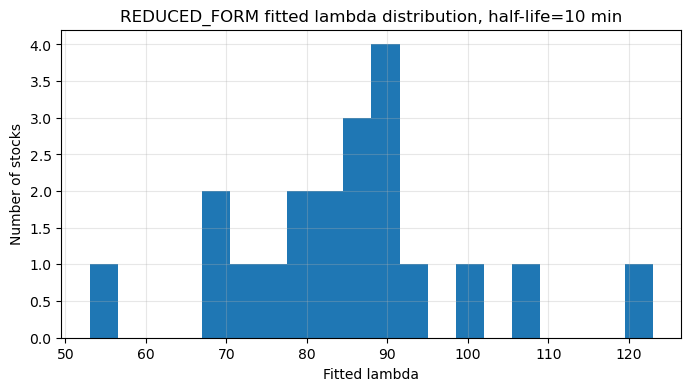

In [30]:
# Plot the distribution of fitted lambda values for the best half-life for each model
for model_type in ["ow", "afs", "reduced_form"]:
    sub = all_results_df[all_results_df["model_type"] == model_type]

    best_half_life = (
        best_by_is
        .loc[best_by_is["model_type"] == model_type, "half_life_minutes"]
        .iloc[0]
    )

    best_half_life_seconds = int(best_half_life * 60)

    sub_best = sub[sub["half_life_seconds"] == best_half_life_seconds]

    plt.figure(figsize=(8, 4))
    plt.hist(sub_best["lambda_hat"], bins=20)
    plt.xlabel("Fitted lambda")
    plt.ylabel("Number of stocks")
    plt.title(
        f"{model_type.upper()} fitted lambda distribution, "
        f"half-life={best_half_life:.0f} min"
    )
    plt.grid(True, alpha=0.3)
    plt.show()